In [54]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [55]:
import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


In [56]:
#Q1
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, t in zip(["a", "b", "c"], [a, b, c]):
    print(f"\n{name}:")
    print(t)
    print(f"shape: {t.shape}")
    print(f"dtype: {t.dtype}")
    print(f"device: {t.device}")

#Comment:
#All tensors are currently on the CPU.
#If your model is on the GPU but your inputs are on the CPU, PyTorch will throw an error. Both must be on the same device so computations can happen efficiently.


a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

c:
tensor([1., 1., 1., 1.])
shape: torch.Size([4])
dtype: torch.float32
device: cpu


In [57]:
#Q2
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
print("sqrt:", torch.sqrt(x))
print("sum:", x.sum())
print("mean:", x.mean())
print("argmax:", x.argmax())

#Comment:
#.argmax() returns the index of the highest score.
#In a classifier with 1000 outputs, it gives you the predicted class index

sqrt: tensor([1., 2., 3., 4., 5.])
sum: tensor(55.)
mean: tensor(11.)
argmax: tensor(4)


In [58]:
#Q3
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

#Comment:
#NumPy only works on CPU memory, so tensors must be moved back using .cpu() first

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


In [59]:
#Q4
t = torch.arange(24).float()

t1 = t.reshape(4, 6)
print("Shape (4,6):", t1.shape)

t2 = t.reshape(2, 3, 4)
print("Shape (2,3,4):", t2.shape)

t3 = t1.unsqueeze(0)
print("After unsqueeze:", t3.shape)

#Comment:
#.unsqueeze(0) adds a batch dimension → turning (C,H,W) into (1,C,H,W), which models require

Shape (4,6): torch.Size([4, 6])
Shape (2,3,4): torch.Size([2, 3, 4])
After unsqueeze: torch.Size([1, 4, 6])


In [60]:
#Q5
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

np_result = np.matmul(np_a, np_b)
torch_result = torch.matmul(t_a, t_b)

print("NumPy result:\n", np_result)
print("PyTorch result:\n", torch_result)

print("Match:", np.allclose(np_result, torch_result.numpy()))

#Matrix multiplication is how neural networks transform inputs through layers (weights × inputs).

NumPy result:
 [[19. 22.]
 [43. 50.]]
PyTorch result:
 tensor([[19., 22.],
        [43., 50.]])
Match: True


In [61]:
#Pretrained Models
#Q1
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

#Pretrained models save massive time and compute, letting you reuse learned features instead of training from scratch.

Total parameters:     11,689,512
Trainable parameters: 11,689,512


In [62]:
#Q2
print(model)

"""Comment:

Final layer: fc
Output size: 1000 classes

“Deep” means many stacked layers learning increasingly complex features (edges → textures → objects)."""


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

'Comment:\n\nFinal layer: fc\nOutput size: 1000 classes\n\n“Deep” means many stacked layers learning increasingly complex features (edges → textures → objects).'

In [63]:
#Q3
model = model.to(device)
model.eval()

print("Model ready for inference.")

"""Comment:

.to(device) → moves model to GPU/CPU
.eval() → disables training behaviors (e.g., dropout, batch norm updates"""

Model ready for inference.


'Comment:\n\n.to(device) → moves model to GPU/CPU\n.eval() → disables training behaviors (e.g., dropout, batch norm updates'

In [64]:
#Q4
preprocess = weights.transforms()
print(preprocess)
"""Comment:

Resize/crop → standardizes input size
ToTensor → converts pixels from [0–255] → [0–1]
Normalize → matches ImageNet training distribution for accuracy"""

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


'Comment:\n\nResize/crop → standardizes input size\nToTensor → converts pixels from [0–255] → [0–1]\nNormalize → matches ImageNet training distribution for accuracy'

In [65]:
import torch
import torchvision
from torchvision import models
from torchvision.models import ResNet18_Weights
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load pretrained model
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

model = model.to(device)
model.eval()

# preprocessing
preprocess = weights.transforms()

print("Model ready on:", device)

Model ready on: cuda


In [71]:
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")

LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

# ✅ VERIFY PATH (CRITICAL)
print("DATA_DIR exists:", DATA_DIR.exists())
print("Mountain folder exists:", (DATA_DIR / "mountain").exists())

DATA_DIR exists: True
Mountain folder exists: True


In [73]:
def load_sample_image(label):
    class_dir = DATA_DIR / label
    
    if not class_dir.exists():
        raise ValueError(f"Folder not found: {class_dir}")
    
    # get ALL files (handles jpg/jpeg/png automatically)
    image_files = [f for f in class_dir.iterdir() if f.is_file()]
    
    if len(image_files) == 0:
        raise ValueError(f"No images found in {class_dir}")
    
    img_path = random.choice(image_files)
    return Image.open(img_path).convert("RGB"), img_path.name

In [74]:
imagenet_classes = weights.meta["categories"]

print("Number of classes:", len(imagenet_classes))
print("First 5:", imagenet_classes[:5])

Number of classes: 1000
First 5: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [75]:
import torch.nn.functional as F

def get_top5_predictions(model, preprocess, image, device, class_labels):
    
    # preprocess
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # inference
    with torch.no_grad():
        output = model(input_tensor)
    
    # probabilities
    probs = F.softmax(output[0], dim=0)
    
    # top-5
    top_probs, top_indices = torch.topk(probs, 5)
    
    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))
    
    return results

In [76]:
img, img_name = load_sample_image("mountain")

preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"{class_name:30s} {prob:.4f}")


Top-5 predictions for '24204.jpg':
alp                            0.4911
volcano                        0.2076
valley                         0.2016
promontory                     0.0184
mountain tent                  0.0169


In [77]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    
    print(f"\n[{label}] {img_name}")
    for class_name, prob in preds:
        print(f"{class_name:30s} {prob:.4f}")


[buildings] 24258.jpg
palace                         0.4301
gondola                        0.1305
monastery                      0.0624

[forest] 23309.jpg
viaduct                        0.3853
totem pole                     0.1089
cliff                          0.0419

[glacier] 20272.jpg
volcano                        0.3854
valley                         0.3297
promontory                     0.1216

[mountain] 20662.jpg
ski                            0.5933
alp                            0.3821
snowmobile                     0.0071

[sea] 23069.jpg
seashore                       0.2016
breakwater                     0.1834
geyser                         0.1718

[street] 24269.jpg
unicycle                       0.1299
triumphal arch                 0.1268
jinrikisha                     0.1049


In [78]:
img, _ = load_sample_image("forest")

input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Sum of probs: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}")

Logit range: min=-4.87, max=6.61
Prob range: min=0.000001, max=0.0979
Sum of probs: 1.000000
Top prediction: mountain bike


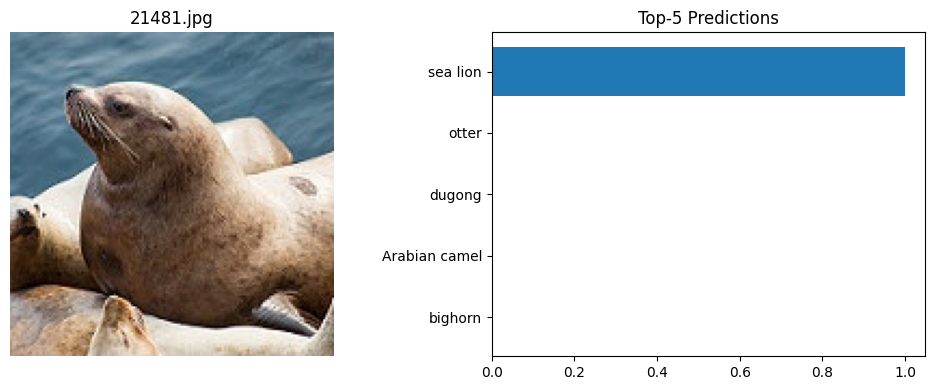

In [79]:
img, img_name = load_sample_image("sea")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# image
axes[0].imshow(img)
axes[0].set_title(img_name)
axes[0].axis("off")

# bar chart
classes = [p[0] for p in preds]
probs = [p[1] for p in preds]

axes[1].barh(classes[::-1], probs[::-1])
axes[1].set_title("Top-5 Predictions")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()